# JENDL-5 Fe-56 MF33 MT2 Uncertainty Diagnostic

Investigate the large uncertainties observed in JENDL-5 Fe-56 elastic scattering
(MT=2) MF33 covariance data. Check LB types (absolute vs relative), `is_relative`
flags, and the app endpoint logic.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from kika.endf.read_endf import read_endf

JENDL5_PATH = '/share_snc/snc/JuanMonleon/JENDL-5/260560.jendl5'
endf = read_endf(JENDL5_PATH, mf_numbers=[2, 3, 33])

mf33 = endf.files.get(33)
print(f"MF33 MT sections: {sorted(mf33.sections.keys())}")

# Reconstruct pointwise cross sections from MF2 resonance parameters + MF3 background
pendf = endf.reconstruct_xs(tolerance=1e-3)
print(f"PENDF MTs: {sorted(pendf.keys())}")
print(f"PENDF MT2 XS at 1 eV: {pendf[2].get_cross_section(1.0):.4f} barns")
print(f"PENDF MT2 XS at 1 keV: {pendf[2].get_cross_section(1e3):.4f} barns")
print(f"PENDF MT2 XS at 1 MeV: {pendf[2].get_cross_section(1e6):.4f} barns")

MF33 MT sections: [1, 2, 4, 16, 22, 28, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 102, 103, 104, 105, 106, 107, 111, 112, 115]
PENDF MTs: [1, 2, 102]
PENDF MT2 XS at 1 eV: 11.9817 barns
PENDF MT2 XS at 1 keV: 9.2663 barns
PENDF MT2 XS at 1 MeV: 1.4318 barns


In [2]:
# Inspect MT2 subsections and LB types
mt2 = mf33.sections[2]
print(f"MT2 subsections: {len(mt2._subsections)}")
for i, sub in enumerate(mt2._subsections):
    print(f"\nSubsection {i}: MT1={sub.mt1}")
    for j, ni in enumerate(sub.ni_records):
        print(f"  NI[{j}]: LB={ni.lb}, NE={ni.ne}, LS={ni.ls}")
        if ni.lb == 5 and ni.matrix:
            print(f"    Matrix elements: {len(ni.matrix)}")
        if ni.lb in (1, 2) and ni.e_table_k:
            print(f"    E-table length: {len(ni.e_table_k)}")
    for j, nc in enumerate(sub.nc_records):
        print(f"  NC[{j}]: LTY={nc.lty}")

MT2 subsections: 1

Subsection 0: MT1=2
  NI[0]: LB=0, NE=3, LS=None
  NC[0]: LTY=0


In [3]:
# Convert to CrossSectionCovariance using reconstructed cross sections
# Merge raw MF3 (smooth reactions) with PENDF (resonance-reconstructed MTs)
sibling = {int(mt): sec for mt, sec in mf33.sections.items() if int(mt) != 2}
mf3_secs = {int(mt): sec for mt, sec in endf.files[3].sections.items()}
for mt_r, sec_r in pendf.items():
    mf3_secs[int(mt_r)] = sec_r  # overwrite with reconstructed

mt2 = mf33.sections[2]
xs_cov = mt2.to_xs_covmat(sibling_sections=sibling, mf3_sections=mf3_secs)

print(f"Number of matrices: {xs_cov.num_matrices}")
print(f"is_relative flags: {xs_cov.is_relative}")
print(f"Energy grids: {len(xs_cov.energy_grids)} grids")

for i, mat in enumerate(xs_cov.matrices):
    diag = np.diag(mat)
    is_rel = xs_cov.is_relative[i] if i < len(xs_cov.is_relative) else 'NOT SET'
    grid = xs_cov.energy_grids[i] if i < len(xs_cov.energy_grids) else None
    
    print(f"\nMatrix {i}: shape={mat.shape}, is_relative={is_rel}")
    if grid:
        print(f"  Energy range: [{grid[0]:.4e}, {grid[-1]:.4e}] eV")
    print(f"  Diagonal range: [{diag.min():.4e}, {diag.max():.4e}]")
    print(f"  sqrt(diag) range: [{np.sqrt(np.maximum(diag, 0)).min():.4e}, {np.sqrt(np.maximum(diag, 0)).max():.4e}]")
    
    if is_rel is True or is_rel == 'NOT SET':
        unc_pct = np.sqrt(np.maximum(diag, 0)) * 100
        print(f"  As relative %: [{unc_pct.min():.2f}%, {unc_pct.max():.2f}%]")

Number of matrices: 1
is_relative flags: [True]
Energy grids: 1 grids

Matrix 0: shape=(217, 217), is_relative=True
  Energy range: [1.0000e-05, 2.0000e+08] eV
  Diagonal range: [0.0000e+00, 1.5506e+00]
  sqrt(diag) range: [0.0000e+00, 1.2452e+00]
  As relative %: [0.00%, 124.52%]


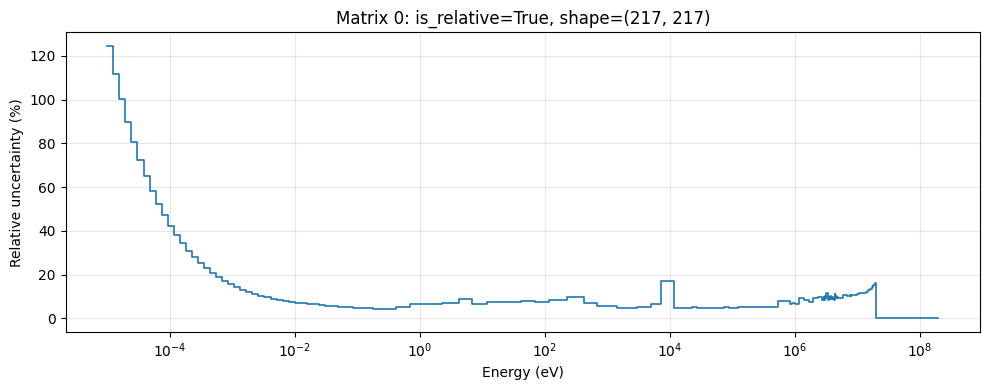

In [4]:
# Plot uncertainties per matrix, handling relative vs absolute correctly
n_mats = len(xs_cov.matrices)
fig, axes = plt.subplots(n_mats, 1, figsize=(10, 4 * max(n_mats, 1)), squeeze=False)

for i, mat in enumerate(xs_cov.matrices):
    ax = axes[i, 0]
    grid = np.array(xs_cov.energy_grids[i]) if i < len(xs_cov.energy_grids) else None
    if grid is None:
        continue

    diag = np.diag(mat)
    is_rel = xs_cov.is_relative[i] if i < len(xs_cov.is_relative) else True

    if is_rel:
        unc = np.sqrt(np.maximum(diag, 0)) * 100
        ylabel = 'Relative uncertainty (%)'
    else:
        unc = np.sqrt(np.maximum(diag, 0))
        ylabel = 'Absolute std dev (barns)'

    ax.step(grid, np.append(unc, unc[-1]), where='post', linewidth=1.2)
    ax.set_xscale('log')
    ax.set_ylabel(ylabel)
    ax.set_title(f'Matrix {i}: is_relative={is_rel}, shape={mat.shape}')
    ax.set_xlabel('Energy (eV)')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [5]:
# Verify uncertainty values at key energies
grid = np.array(xs_cov.energy_grids[0])
diag = np.diag(xs_cov.matrices[0])
unc_pct = np.sqrt(np.maximum(diag, 0)) * 100

print("Uncertainty at key energies:")
for e_query in [0.0253, 1.0, 1e3, 1e5, 1e6, 5e6, 1e7, 1.5e7, 2e7]:
    idx = np.searchsorted(grid, e_query) - 1
    if 0 <= idx < len(unc_pct):
        print(f"  {e_query:.4g} eV: {unc_pct[idx]:.2f}%")

print(f"\nMax uncertainty: {unc_pct.max():.2f}% at group {np.argmax(unc_pct)}")
print(f"Median uncertainty: {np.median(unc_pct[unc_pct > 0]):.2f}%")

Uncertainty at key energies:
  0.0253 eV: 6.22%
  1 eV: 6.50%
  1000 eV: 5.80%
  1e+05 eV: 5.01%
  1e+06 eV: 7.23%
  5e+06 eV: 9.71%
  1e+07 eV: 10.85%
  1.5e+07 eV: 12.28%
  2e+07 eV: 16.33%

Max uncertainty: 124.52% at group 0
Median uncertainty: 8.54%
